# Graphs with matplotlib (very basic introduction)

Jordi Duarte-Campderros

jordi.duarte@unican.es

(based on Nikolay Koldunov's notes [python for geoscience](https://github.com/koldunovn/python_for_geosciences))

This is part of [**M1992 Programming for scientific environment**](https://moodle.unican.es/course/view.php?id=15738) course notes.

=============

This jupyter notebook is in response to the assignment of the Programming subject of the MSc in Particle Physics and Cosmology at the UC that I (Joan Ribot Oliver, from Manacor, Mallorca) am currently studying.

The assignment asks to follow this tutorial and make the plots asked. The document must also be rendered as a .html.

[Matplotlib](http://matplotlib.org/) is a python 2D plotting library which produces publication quality figures in a variety of hardcopy formats and interactive environments across platforms.

Usually we import `matplotlib` as follows:

In [1]:
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np

This allows inline graphics in IPython (Jupyter) notebooks and imports functions nessesary for ploting as `plt`. In addition we import `numpy` as `np`.

Let's prepare some data:

In [2]:
x = np.linspace(0,10,30)
y = x ** 2

Plot is as easy as this:

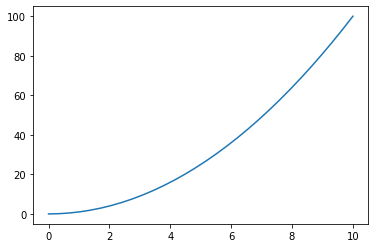

In [3]:
plt.plot(x,y);

Line style and labels are controlled in a way similar to Matlab:

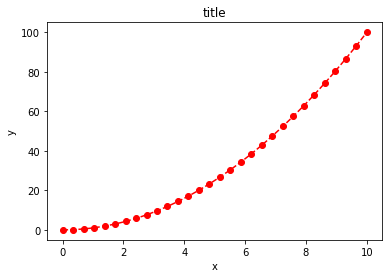

In [4]:
plt.plot(x, y, 'r--o')
plt.xlabel('x')
plt.ylabel('y')
plt.title('title');

You can plot several individual lines at once:

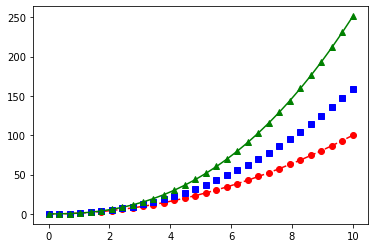

In [5]:
plt.plot(x, y, 'r--o', x, y ** 1.1, 'bs', x, y ** 1.2, 'g^-' );

## Exercise

- plot sine (np.sin())
- plot sine abd cosine on one plot
- make sine thicker (linewidth=5) and sine dashed

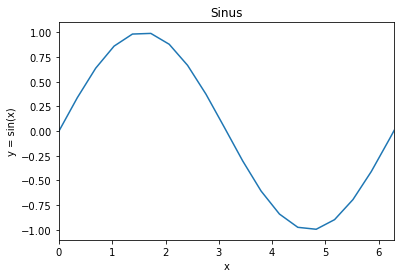

In [6]:
x = np.linspace(0, 10, 30)
y_sin = np.sin(x)
plt.plot(x,y_sin)
plt.xlabel('x')
plt.ylabel('y = sin(x)')
plt.title('Sinus')
plt.xlim(0,6.283)
plt.ylim(-1.1,1.1);

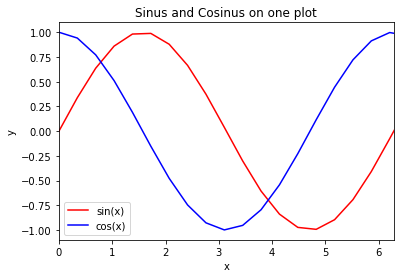

In [7]:
y_cos = np.cos(x)
plt.plot(x, y_sin, 'r', x, y_cos, 'b')
plt.title('Sinus and Cosinus on one plot')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0,6.283);
plt.legend(['sin(x)', 'cos(x)']);

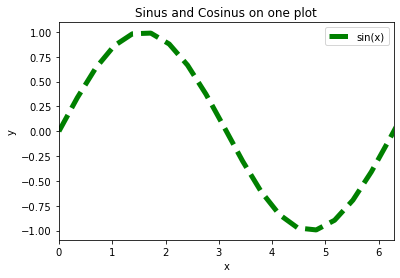

In [8]:
y_cos = np.cos(x)
plt.plot(x, y_sin, 'g--', linewidth=5)
plt.title('Sinus and Cosinus on one plot')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0,6.283);
plt.legend(['sin(x)', 'cos(x)']);

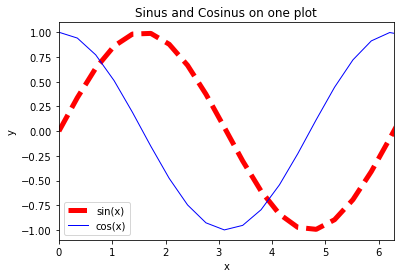

In [9]:
y_cos = np.cos(x)
plt.plot(x, y_sin, 'r--', linewidth=5)
plt.plot(x, y_cos, 'b', linewidth=1)
plt.title('Sinus and Cosinus on one plot')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0,6.283);
plt.legend(['sin(x)', 'cos(x)']);

### Alternatives

- [Bokeh](http://bokeh.pydata.org/)
- [plot.ly](http://plot.ly)
- [ggplot](https://ggplot2.tidyverse.org)

One more example:

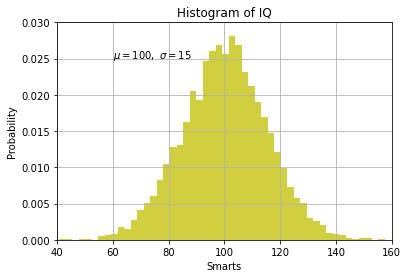

In [10]:
mu, sigma = 100, 15
x = mu + sigma * np.random.randn(10000)

# the histogram of the data
n, bins, patches = plt.hist(x, 50, density=True, facecolor='y', alpha=0.75)

plt.xlabel('Smarts')
plt.ylabel('Probability')
plt.title('Histogram of IQ')
plt.text(60, .025, r'$\mu=100,\ \sigma=15$')
plt.axis([40, 160, 0, 0.03])
plt.grid(True)

If you feel a bit playful:

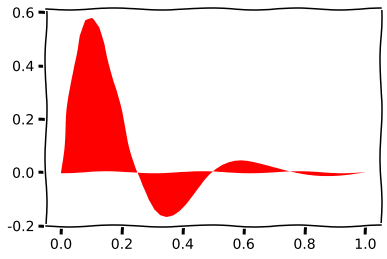

In [14]:
import matplotlib.pyplot as plt
plt.xkcd()  # <-- enables xkcd-style plotting
with plt.xkcd():
    x = np.linspace(0, 1)
    y = np.sin(4 * np.pi * x) * np.exp(-5 * x)

    plt.fill(x, y, 'r')
    plt.grid(False)

Following example is from [matplotlib - 2D and 3D plotting in Python](http://nbviewer.ipython.org/urls/raw.github.com/jrjohansson/scientific-python-lectures/master/Lecture-4-Matplotlib.ipynb) - great place to start for people interested in matplotlib.


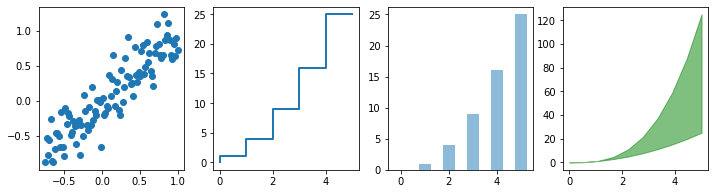

In [12]:
n = np.array([0,1,2,3,4,5])
xx = np.linspace(-0.75, 1., 100)
x = np.linspace(0, 5, 10)

fig, axes = plt.subplots(1, 4, figsize=(12,3))

axes[0].scatter(xx, xx + 0.25*np.random.randn(len(xx)))

axes[1].step(n, n**2, lw=2)

axes[2].bar(n, n**2, align="center", width=0.5, alpha=0.5)

axes[3].fill_between(x, x**2, x**3, color="green", alpha=0.5);

## Learning from the past

When you going to plot something more or less complicated in Matplotlib, the first thing you do is open the [Matplotlib example gallery](https://matplotlib.org/stable/gallery/index.html) and choose example closest to your case.

You can directly load python code (or basically any text file) to the notebook. This time we download code from the Matplotlib example gallery:

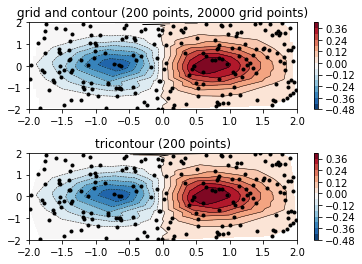

In [13]:
# %load https://matplotlib.org/stable/_downloads/758c39512ff467ae08f5d49cccfb7f30/irregulardatagrid.py
"""
=======================================
Contour plot of irregularly spaced data
=======================================

Comparison of a contour plot of irregularly spaced data interpolated
on a regular grid versus a tricontour plot for an unstructured triangular grid.

Since `~.axes.Axes.contour` and `~.axes.Axes.contourf` expect the data to live
on a regular grid, plotting a contour plot of irregularly spaced data requires
different methods. The two options are:

* Interpolate the data to a regular grid first. This can be done with on-board
  means, e.g. via `~.tri.LinearTriInterpolator` or using external functionality
  e.g. via `scipy.interpolate.griddata`. Then plot the interpolated data with
  the usual `~.axes.Axes.contour`.
* Directly use `~.axes.Axes.tricontour` or `~.axes.Axes.tricontourf` which will
  perform a triangulation internally.

This example shows both methods in action.
"""

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.tri as tri

np.random.seed(19680801)
npts = 200
ngridx = 100
ngridy = 200
x = np.random.uniform(-2, 2, npts)
y = np.random.uniform(-2, 2, npts)
z = x * np.exp(-x**2 - y**2)

fig, (ax1, ax2) = plt.subplots(nrows=2)

# -----------------------
# Interpolation on a grid
# -----------------------
# A contour plot of irregularly spaced data coordinates
# via interpolation on a grid.

# Create grid values first.
xi = np.linspace(-2.1, 2.1, ngridx)
yi = np.linspace(-2.1, 2.1, ngridy)

# Linearly interpolate the data (x, y) on a grid defined by (xi, yi).
triang = tri.Triangulation(x, y)
interpolator = tri.LinearTriInterpolator(triang, z)
Xi, Yi = np.meshgrid(xi, yi)
zi = interpolator(Xi, Yi)

# Note that scipy.interpolate provides means to interpolate data on a grid
# as well. The following would be an alternative to the four lines above:
# from scipy.interpolate import griddata
# zi = griddata((x, y), z, (xi[None, :], yi[:, None]), method='linear')

ax1.contour(xi, yi, zi, levels=14, linewidths=0.5, colors='k')
cntr1 = ax1.contourf(xi, yi, zi, levels=14, cmap="RdBu_r")

fig.colorbar(cntr1, ax=ax1)
ax1.plot(x, y, 'ko', ms=3)
ax1.set(xlim=(-2, 2), ylim=(-2, 2))
ax1.set_title('grid and contour (%d points, %d grid points)' %
              (npts, ngridx * ngridy))

# ----------
# Tricontour
# ----------
# Directly supply the unordered, irregularly spaced coordinates
# to tricontour.

ax2.tricontour(x, y, z, levels=14, linewidths=0.5, colors='k')
cntr2 = ax2.tricontourf(x, y, z, levels=14, cmap="RdBu_r")

fig.colorbar(cntr2, ax=ax2)
ax2.plot(x, y, 'ko', ms=3)
ax2.set(xlim=(-2, 2), ylim=(-2, 2))
ax2.set_title('tricontour (%d points)' % npts)

plt.subplots_adjust(hspace=0.5)
plt.show()

# %%
#
# .. admonition:: References
#
#    The use of the following functions, methods, classes and modules is shown
#    in this example:
#
#    - `matplotlib.axes.Axes.contour` / `matplotlib.pyplot.contour`
#    - `matplotlib.axes.Axes.contourf` / `matplotlib.pyplot.contourf`
#    - `matplotlib.axes.Axes.tricontour` / `matplotlib.pyplot.tricontour`
#    - `matplotlib.axes.Axes.tricontourf` / `matplotlib.pyplot.tricontourf`
